In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

2026-08-11 01:43:30.515587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786423410.535659  611473 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786423410.541515  611473 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-11 01:43:30.566534: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [11]:
# ---- 1. Reuse your actual parsing + index functions ----

def _parse_example(example_proto):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)
    x.set_shape((128, 128, 4))
    y.set_shape((128, 128, 1))
    scene = parsed["scene"]
    return x, y, scene

In [12]:
def _add_indices(x, y):
    blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)
    return x, y

In [13]:
def _add_indices_with_scene(x, y, scene):
    # wrapper so scene passes through the (x, y) -> 7-channel transform untouched
    x, y = _add_indices(x, y)
    return x, y, scene

In [14]:
tfrecord_path = base_path / "data" / "tfrecords"
model_path = base_path / "models" / "unet_sugarcane_best.keras"

In [15]:
# ---- 2. Build eval dataset: parse -> add indices, NO augmentation ----

test_files = sorted(str(p) for p in tfrecord_path.glob("test_*.tfrecord"))
test_ds = (
    tf.data.TFRecordDataset(test_files)
    .map(_parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    .map(_add_indices_with_scene, num_parallel_calls=tf.data.AUTOTUNE)
)

In [ ]:
# custom loss functions for your model, if you used any during training
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [17]:
# ---- 3. Load your trained model ----

model = tf.keras.models.load_model(model_path, custom_objects={'loss_fn': combined_loss})  # fill in
THRESHOLD = 0.5  # use whatever threshold your sweep settled on

In [18]:
# ---- 4. Score every patch, keep per-patch error counts + arrays ----

records = []

for i, (x, y, scene) in enumerate(test_ds):
    x_batch = tf.expand_dims(x, 0)  # now (1, 128, 128, 7)
    pred_prob = model.predict(x_batch, verbose=0)[0]
    pred_mask = (pred_prob > THRESHOLD).astype(np.float32)

    y_np = y.numpy()
    fn = np.sum((y_np == 1) & (pred_mask == 0))
    fp = np.sum((y_np == 0) & (pred_mask == 1))

    records.append({
        "idx": i,
        "scene": scene.numpy().decode("utf-8"),
        "fn_count": int(fn),
        "fp_count": int(fp),
        "x": x.numpy(),   # 7-channel, for reference/debugging if needed
        "y": y_np,
        "pred": pred_mask,
    })

    if i % 200 == 0:
        print(f"scored {i} patches")

print(f"Scored {len(records)} test patches total")

I0000 00:00:1786424421.462708  612690 service.cc:148] XLA service 0x7442bc003b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786424421.486395  612690 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-11 02:00:22.350634: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786424423.519074  612690 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1786424434.136844  612690 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


scored 0 patches
scored 200 patches
scored 400 patches
scored 600 patches
scored 800 patches
scored 1000 patches
scored 1200 patches
scored 1400 patches
scored 1600 patches
scored 1800 patches
scored 2000 patches
scored 2200 patches
scored 2400 patches
scored 2600 patches
scored 2800 patches
scored 3000 patches
scored 3200 patches
scored 3400 patches
scored 3600 patches
scored 3800 patches
scored 4000 patches
scored 4200 patches
scored 4400 patches
scored 4600 patches
scored 4800 patches
Scored 5000 test patches total


2026-08-11 02:06:54.345594: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [22]:
# ---- 5. Rank by worst false negatives and worst false positives ----

worst_fn = sorted(records, key=lambda r: -r["fn_count"])[:20]
worst_fp = sorted(records, key=lambda r: -r["fp_count"])[:20]

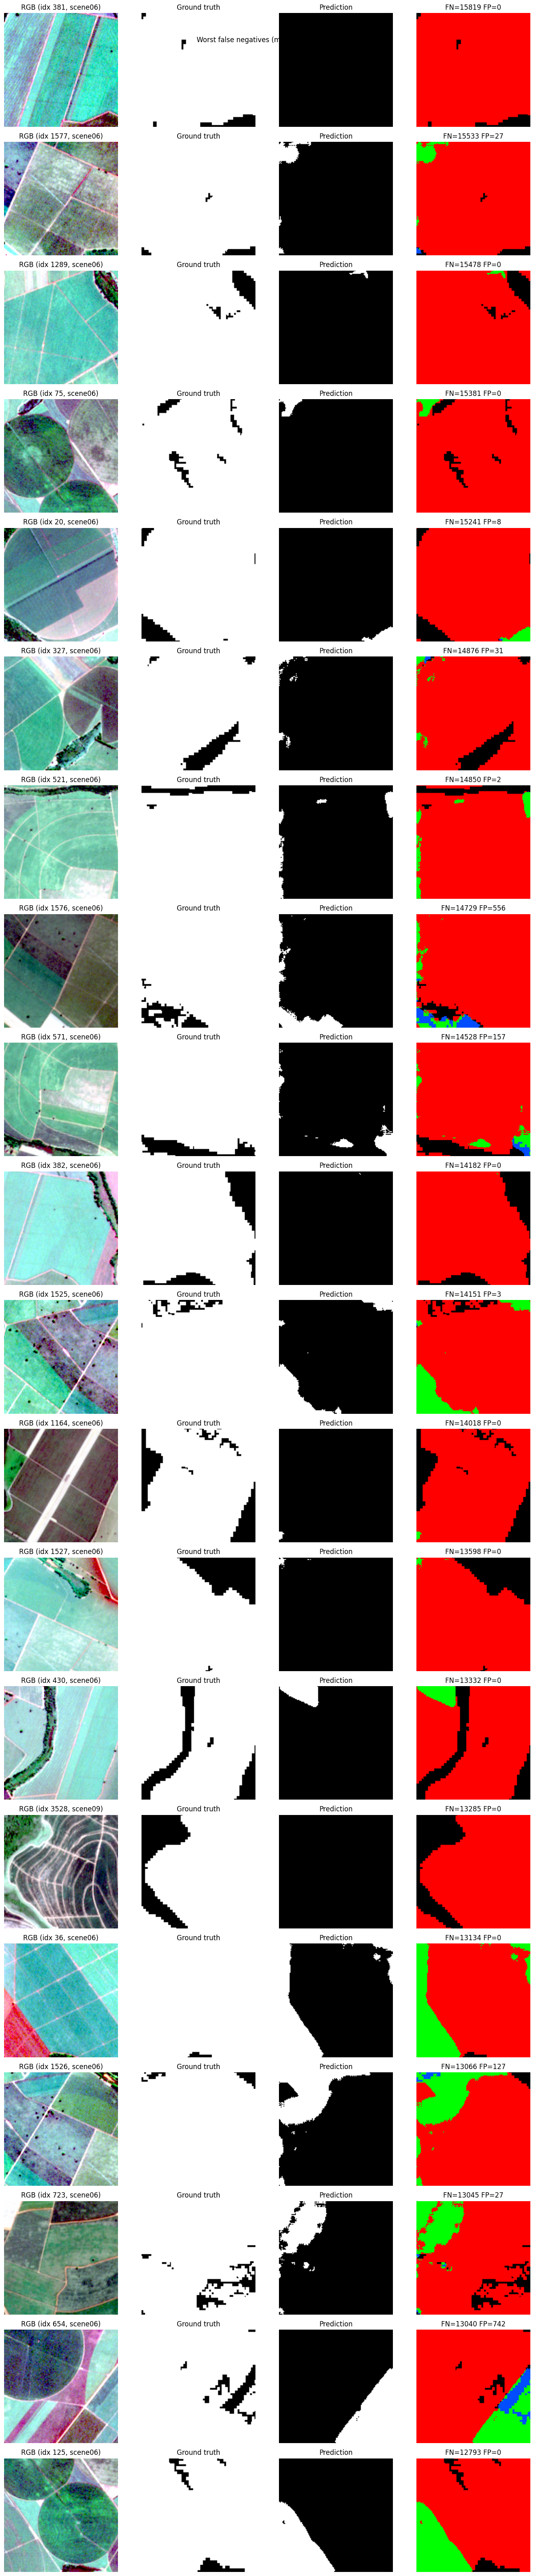

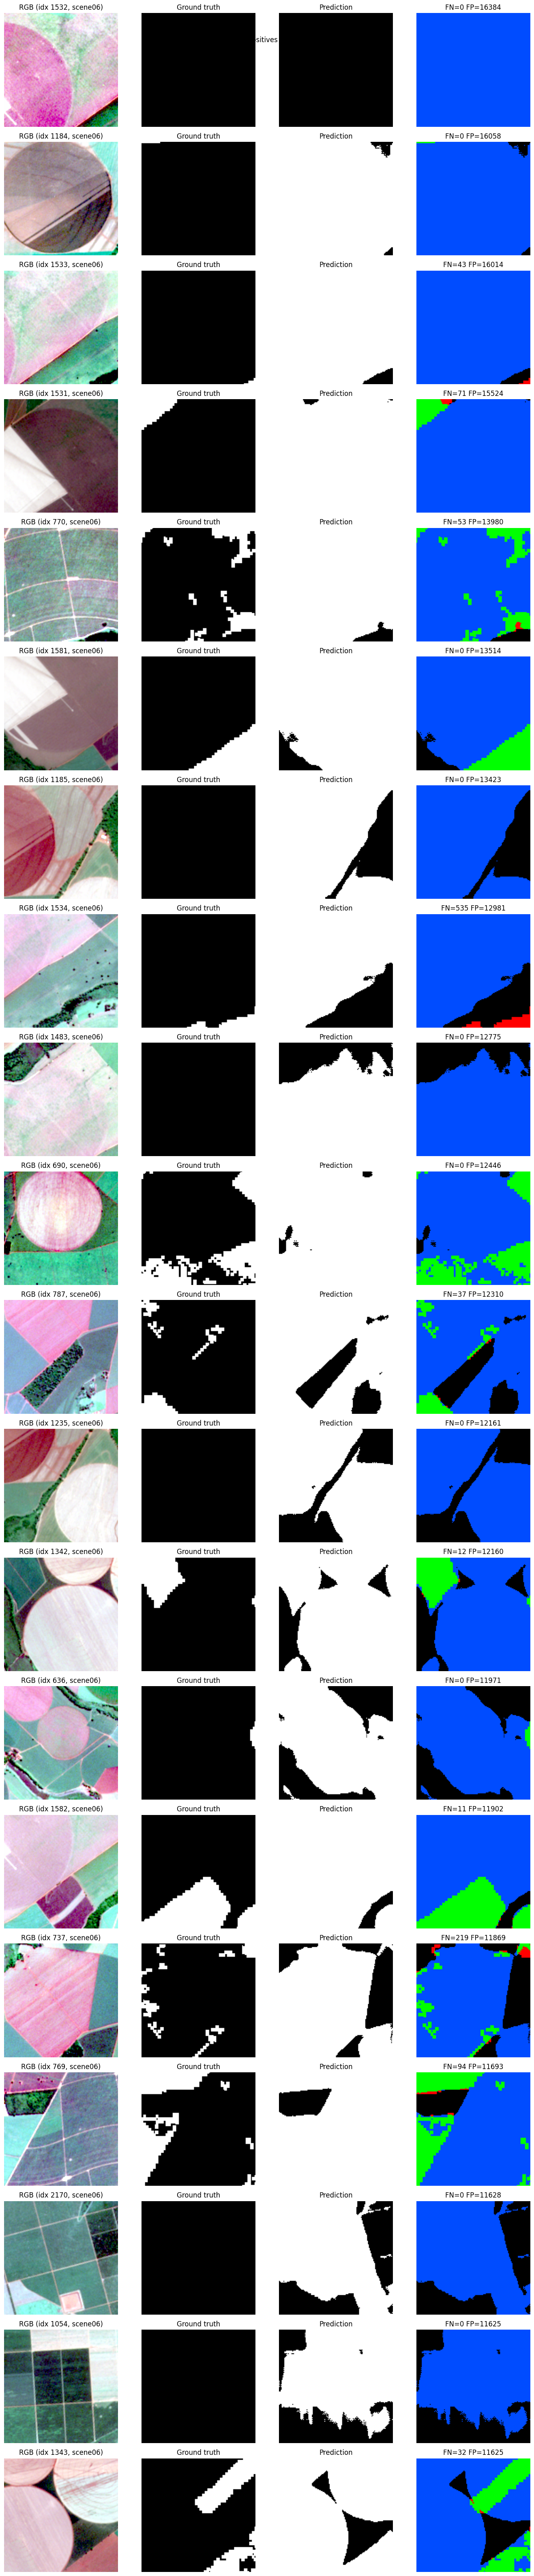

In [23]:
# ---- 6. Visualize: RGB | Ground truth | Prediction | Error map ----

def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()
    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)
        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low + 1e-8)
    return np.power(np.clip(rgb, 0, 1), 1 / gamma)

def show_patch_set(record_list, title):
    n = len(record_list)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n))
    for row, rec in enumerate(record_list):
        # rec["x"] is 7-channel (B,G,R,NIR,NDVI,NDWI,EVI); RGB is still channels 0,1,2
        rgb = stretch_rgb(rec["x"][:, :, [2, 1, 0]])
        gt = rec["y"][:, :, 0]
        pred = rec["pred"][:, :, 0]

        error_map = np.zeros((128, 128, 3))
        error_map[(gt == 1) & (pred == 0)] = [1, 0, 0]      # red = missed (FN)
        error_map[(gt == 0) & (pred == 1)] = [0, 0.3, 1]    # blue = false alarm (FP)
        error_map[(gt == 1) & (pred == 1)] = [0, 1, 0]      # green = correct positive

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f"RGB (idx {rec['idx']}, {rec['scene']})")
        axes[row, 1].imshow(gt, cmap="gray");   axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(pred, cmap="gray"); axes[row, 2].set_title("Prediction")
        axes[row, 3].imshow(error_map);         axes[row, 3].set_title(f"FN={rec['fn_count']} FP={rec['fp_count']}")
        for ax in axes[row]:
            ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_patch_set(worst_fn, "Worst false negatives (missed sugarcane)")
show_patch_set(worst_fp, "Worst false positives (false alarms)")

In [21]:
# ---- 7. Bonus: per-scene error breakdown (now that you have `scene` in TFRecords) ----

from collections import defaultdict
scene_fn = defaultdict(int)
scene_fp = defaultdict(int)
scene_count = defaultdict(int)

for r in records:
    scene_fn[r["scene"]] += r["fn_count"]
    scene_fp[r["scene"]] += r["fp_count"]
    scene_count[r["scene"]] += 1

print("\nPer-scene error totals:")
for scene in sorted(scene_count):
    print(f"  {scene}: {scene_count[scene]} patches, "
          f"total FN={scene_fn[scene]}, total FP={scene_fp[scene]}")


Per-scene error totals:
  scene06: 2500 patches, total FN=3565831, total FP=4288376
  scene09: 2500 patches, total FN=2666423, total FP=1526376


TP (correct sugarcane) NDVI: mean=0.655, std=0.224, n=26178238
FN (missed sugarcane)  NDVI: mean=0.661, std=0.222, n=6232254
FP (false alarm)       NDVI: mean=0.594, std=0.256, n=5814752


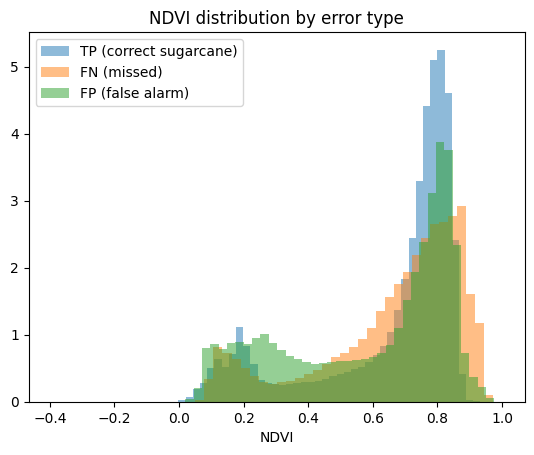

In [24]:
fn_ndvi, fp_ndvi, tp_ndvi = [], [], []

for r in records:
    gt   = r["y"][:, :, 0]
    pred = r["pred"][:, :, 0]
    ndvi = r["x"][:, :, 4]  # channel 4 = NDVI, per _add_indices order

    fn_mask = (gt == 1) & (pred == 0)
    fp_mask = (gt == 0) & (pred == 1)
    tp_mask = (gt == 1) & (pred == 1)

    if fn_mask.sum() > 0: fn_ndvi.extend(ndvi[fn_mask].tolist())
    if fp_mask.sum() > 0: fp_ndvi.extend(ndvi[fp_mask].tolist())
    if tp_mask.sum() > 0: tp_ndvi.extend(ndvi[tp_mask].tolist())

fn_ndvi, fp_ndvi, tp_ndvi = map(np.array, (fn_ndvi, fp_ndvi, tp_ndvi))

print(f"TP (correct sugarcane) NDVI: mean={tp_ndvi.mean():.3f}, std={tp_ndvi.std():.3f}, n={len(tp_ndvi)}")
print(f"FN (missed sugarcane)  NDVI: mean={fn_ndvi.mean():.3f}, std={fn_ndvi.std():.3f}, n={len(fn_ndvi)}")
print(f"FP (false alarm)       NDVI: mean={fp_ndvi.mean():.3f}, std={fp_ndvi.std():.3f}, n={len(fp_ndvi)}")

plt.hist(tp_ndvi, bins=50, alpha=0.5, label="TP (correct sugarcane)", density=True)
plt.hist(fn_ndvi, bins=50, alpha=0.5, label="FN (missed)", density=True)
plt.hist(fp_ndvi, bins=50, alpha=0.5, label="FP (false alarm)", density=True)
plt.xlabel("NDVI"); plt.legend(); plt.title("NDVI distribution by error type")
plt.show()